In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from FAPT import *
from scipy.interpolate import interp1d

s = Simulation()
s.order = 2
N_t = 3000
tg = 250
tlist = np.linspace(0, tg, N_t)
sigma = 0.2

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
rrr, Delta, cos_wd

(np.complex128(10.020548236265341+0j),
 np.complex128(-1.1790890474896738+0j),
 np.float64(4.4411924685191915))

In [2]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg):
    ht, ht_args = h_target(Delta, rrr, tg, sigma_r = sigma)
    return ht, ht_args
ht, args = compute_htarget(tg)

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


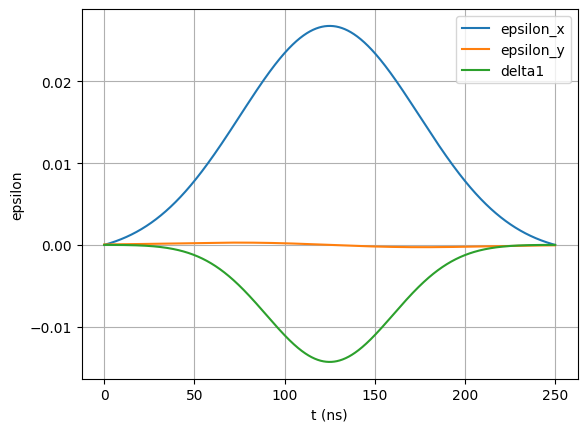

In [3]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t) for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

In [4]:
import pickle
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs


Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [5]:
from scipy.optimize import least_squares

def find_parameter_change_fit(heff_t, prev_solution, t, dt):
    if not prev_solution:
        prev_solution = [cos_wd,cos_amp,0]
    def residuals(x):
        wd, ar, ai = x
        amp = ar + 1j*ai        
        heff_00 = heff_fit(coeffs00, wd, amp)
        heff_11 = heff_fit(coeffs11,wd, amp)
        heff_01 = heff_fit(coeffs01,wd, amp)
        deltadiff = (heff_00 - heff_11) - (heff_t[0,0] - heff_t[1,1])
        omega_diff = heff_01 - heff_t[0,1]

        return np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0], amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1], amp_real_range[1], amp_imag_range[1]]))
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [6]:
# test difference between direct and perfect simulation
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)

def compute_pulse_shape(tlist, ht_func):
    prev_sol = None
    drive_freq_precomputed = []
    drive_amp_real_precomputed = []
    drive_amp_imag_precomputed = []
    dt = tg / N_t
    for t in tqdm(tlist):
        res = find_parameter_change_fit(ht_func(t), prev_sol, t, dt)
        freq= res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [res['dw'], amp_real, amp_imag]
    return np.array(drive_freq_precomputed), np.array(drive_amp_real_precomputed), np.array(drive_amp_imag_precomputed)

force_computation = True
heff_file = coeff_dir / f"precomputed_heff_modulated{tg}_{N_t}.pkl"

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    drive_freq_precomputed, drive_amp_real_precomputed, drive_amp_imag_precomputed = compute_pulse_shape(tlist, ht_func)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"frequency and amplitudes saved to {heff_file}")

100%|██████████| 3000/3000 [00:01<00:00, 1732.68it/s]

frequency and amplitudes saved to /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated250_3000.pkl


In [7]:
def drive_signal_interp(t, freq = drive_freq_precomputed, amp_real = drive_amp_real_precomputed, amp_imag = drive_amp_imag_precomputed):
    if t <= tlist[0]:
        return [freq[0],0]
    if t >= tlist[-1]:
        return [freq[-1],0]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    wd = (1 - alpha) * freq[idx] + alpha * freq[idx + 1]
    ar = (1 - alpha) * amp_real[idx] + alpha * amp_real[idx + 1]
    ai = (1 - alpha) * amp_imag[idx] + alpha * amp_imag[idx + 1]
    return [wd, (ar + 1j*ai)]

In [8]:
# =============================================================================
# ZENTRALE PLOT- UND STYLING-KONFIGURATION (Paper Quality)
# =============================================================================
PAPER_STYLE = {
    # Typography & Schriftgrößen (optimiert für 0.68\textwidth)
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9.5,
    
    # Linien & Ticks
    "lines.linewidth": 1.8,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
    
    # Auflösung & Export-Qualität
    "figure.dpi": 300,         # Vorschau-Auflösung (z.B. in Jupyter)
    "savefig.dpi": 600,        # High-End Export-Auflösung für Rastergrafiken
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42,        # Bettet TrueType-Schriften in PDFs ein (wichtig für IEEE/APS)
    "ps.fonttype": 42,
}


## DRAG Pulse Drive Components

Overview of the time evolution of normalized pulse components over normalized time $t/t_g$:

* **$A_{\mathrm{real}}$ & $A_{\mathrm{imag}}$:** Real (in-phase) and imaginary (quadrature) components of the complex drive amplitude.
* **$\omega_d - \omega_{d,0}$:** Dynamic frequency detuning during the pulse.
* **$\sigma = 0.2\,t_g$:** The pulse width interval $t_{\mathrm{center}} \pm \sigma$ is indicated by dashed lines in all subplots.

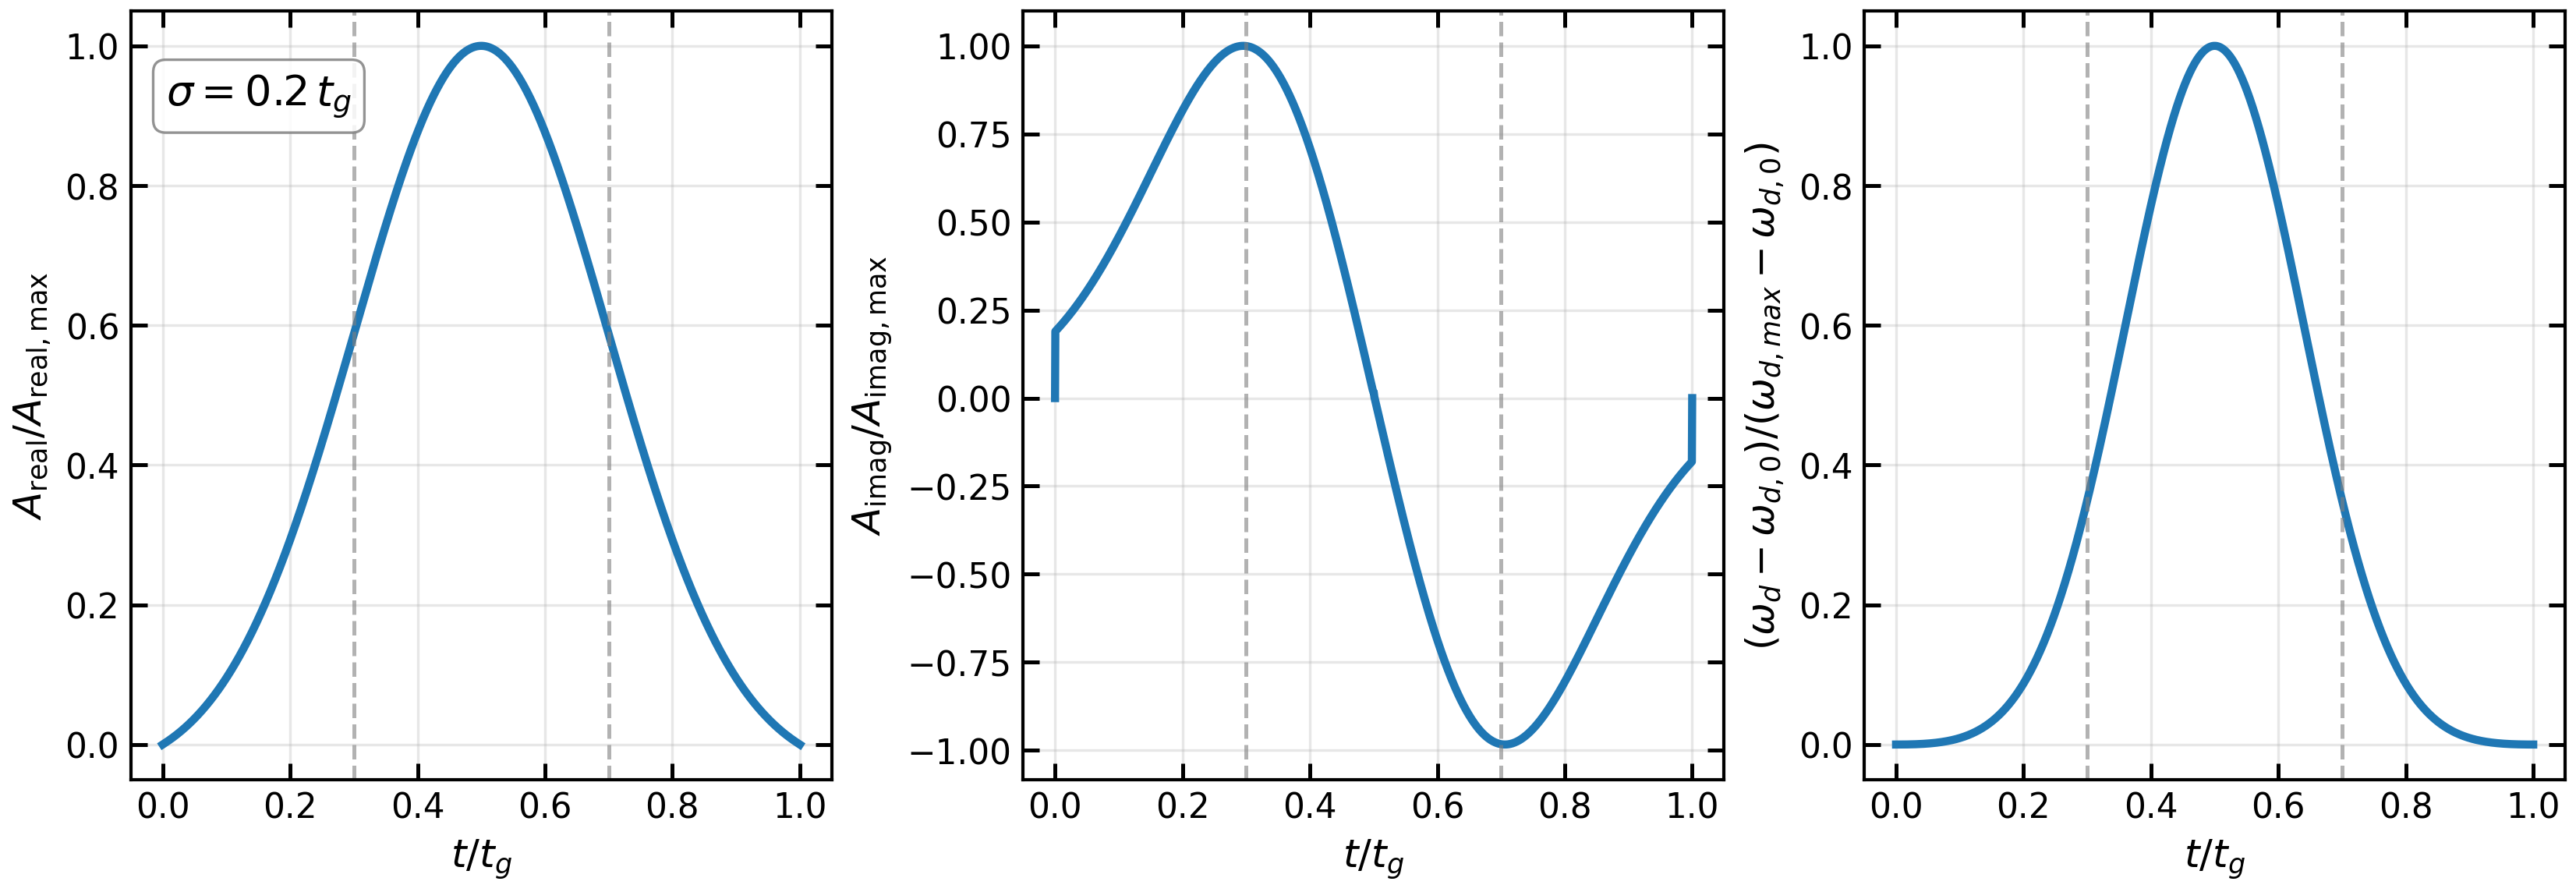

In [9]:
plt.rcParams.update(PAPER_STYLE)
def plot_drive_components(t_end=tg, n=2000):
    t_vals = np.linspace(0, t_end, n)

    A_real = np.array([drive_signal_interp(t)[1].real for t in t_vals])/(2*np.pi)
    A_imag = np.array([drive_signal_interp(t)[1].imag for t in t_vals])/(2*np.pi)
    omega  = np.array([drive_signal_interp(t)[0] for t in t_vals])/(2*np.pi)

    # Normalize
    t = t_vals / t_end

    A_real_max = np.max(np.abs(A_real))
    A_imag_max = np.max(np.abs(A_imag))

    omega0 = omega[0]
    domega_max = np.max(np.abs(omega - omega0))

    _, axes = plt.subplots(
        1, 3,
        figsize=(11, 3.8),
        constrained_layout=True
    )

    lw = 2.5

    # Subplot 1: A_real
    axes[0].plot(t, A_real/A_real_max, lw=lw)
    axes[0].set_xlabel(r"$t/t_g$")
    axes[0].set_ylabel(r"$A_{\mathrm{real}}/A_{\mathrm{real,max}}$")
    axes[0].grid(alpha=0.3)

    # Subplot 2: A_imag
    axes[1].plot(t, A_imag/A_imag_max, lw=lw)
    axes[1].set_xlabel(r"$t/t_g$")
    axes[1].set_ylabel(r"$A_{\mathrm{imag}}/A_{\mathrm{imag,max}}$")
    axes[1].grid(alpha=0.3)

    # Subplot 3: Detuning / Frequency
    axes[2].plot(t, (omega-omega0)/domega_max, lw=lw)
    axes[2].set_xlabel(r"$t/t_g$")
    axes[2].set_ylabel(r"$(\omega_d-\omega_{d,0})/(\omega_{d,max}-\omega_{d,0})$")
    axes[2].grid(alpha=0.3)

    # --- 1. Textbox für \sigma im ersten Subplot (KORRIGIERT: rf"...") ---
    axes[0].text(
        0.05, 0.92,
        rf"$\sigma = {sigma}\,t_g$",
        transform=axes[0].transAxes,
        fontsize=13,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray", lw=0.8)
    )

    # --- 2. Vertikale Linien bei t_center +/- sigma für ALLE 3 Subplots ---
    t_center = 0.5
    for ax in axes:  # Jetzt auf allen 3 Subplots
        ax.axvline(t_center - sigma, color="gray", linestyle="--", lw=1.2, alpha=0.6)
        ax.axvline(t_center + sigma, color="gray", linestyle="--", lw=1.2, alpha=0.6)

    # Axis Formatting
    for ax in axes:
        ax.tick_params(
            direction="in",
            top=True,
            right=True,
            length=5,
            width=1.2
        )

    plt.savefig("Figure/drive_components.png", bbox_inches="tight")
    plt.show()

plot_drive_components()

## Population Dynamics: DRAG vs. Cosine Drive ($t_g = 1.0\ \mu\text{s}$)

Comparison of state populations $|\langle i|\psi(t)\rangle|^2$ for states $i \in \{a, b, c\}$ at $t_g = 1.0\ \mu\text{s}$ ($1000\ \text{ns}$):

* **DRAG Drive:** Shapes complex pulse components ($a_r, a_i$) to suppress leakage into state $|c\rangle$, achieving complete transfer from $|a\rangle$ to $|b\rangle$ at $t/t_g = 1.0$.
* **Cosine Drive:** Uses standard $A_{\text{cos}}\cos(\omega_d t)$ drive. Broad spectral width causes off-resonant leakage into $|c\rangle$ and incomplete transfer to $|b\rangle$.
* **Key Takeaway:** DRAG eliminates parasitic $|c\rangle$ excitation and maximizes transfer fidelity at $t_g = 1.0\ \mu\text{s}$.

In [10]:
def compute_drag_vs_cosine_trajectories(s, tg_ns=1000.0, N_t=200, sigma=0.2):
    r"""
    Berechnet die Zeitentwicklung der Populationen (|a>, |b>, |c>) für:
      1. DRAG-Puls
      2. Cosine-Puls (lh = [s.H0, [s.V1, lambda t: cos_amp * np.cos(cos_wd * t)]])
      
    Standardmäßig für tg_ns = 1000.0 ns (1.0 \mu s).
    """
    tlist = np.linspace(0, tg_ns, N_t)
    
    # --- 1. Parameter für den Cosine-Puls berechnen ---
    cos_amp, cos_wd = compute_cos_params(s, tg_ns)
    
    # Cosine-Simulation
    lh_cos = [s.H0, [s.V1, lambda t, args=None: cos_amp * np.cos(cos_wd * t)]]
    amp_cos = resonant_subspace_column_evolution(lh_cos, tlist, 0, debug=False, s=s)
    
    pop_cosine = {
        "state_a": np.abs(amp_cos[0])**2,
        "state_b": np.abs(amp_cos[1])**2,
        "state_c": np.abs(amp_cos[2])**2 if len(amp_cos) > 2 else np.zeros_like(tlist)
    }

    # --- 2. DRAG Puls-Shape Berechnung ---
    heff_params = s.heff(cos_wd, cos_amp)
    Delta = heff_params[2][2] - heff_params[0][0]
    rrr = heff_params[1][2] / heff_params[0][1]
    ht, _ = h_target(Delta, rrr, tg_ns, sigma_r=sigma)
    ht_func = lambda t: ht[0] + sum(h[0] * h[1](t) for h in ht[1:])
    
    freq, ar, ai = [], [], []
    prev_sol = [cos_wd, cos_amp, 0]
    bounds = (
        [0.7 * 2 * np.pi, -2 * np.pi, -np.pi / 4],
        [0.712 * 2 * np.pi, 2 * np.pi, np.pi / 4],
    )
    for t in tqdm(tlist, desc=f"DRAG Pulse Shape (tg = {tg_ns/1000.0:.1f} µs / {tg_ns:.0f} ns)", leave=False):
        ht_t = ht_func(t)
        def res(x):
            w, a_r, a_i = x
            amp = a_r + 1j * a_i
            diff_diag = (
                heff_fit(coeffs00, w, amp) - heff_fit(coeffs11, w, amp)
            ) - (ht_t[0, 0] - ht_t[1, 1])
            diff_off = heff_fit(coeffs01, w, amp) - ht_t[0, 1]
            return [abs(diff_diag), np.real(diff_off), np.imag(diff_off)]
        opt = least_squares(res, x0=prev_sol, bounds=bounds)
        prev_sol = opt.x
        freq.append(opt.x[0])
        ar.append(opt.x[1])
        ai.append(opt.x[2])
        
    freq, ar, ai = np.array(freq), np.array(ar), np.array(ai)
    
    f_wd = interp1d(tlist, freq, kind="linear", bounds_error=False, fill_value=(freq[0], freq[-1]))
    f_ar = interp1d(tlist, ar, kind="linear", bounds_error=False, fill_value=(ar[0], ar[-1]))
    f_ai = interp1d(tlist, ai, kind="linear", bounds_error=False, fill_value=(ai[0], ai[-1]))

    def qutip_signal(t, args=None):
        w = float(f_wd(t))
        r = float(f_ar(t))
        i = float(f_ai(t))
        return r * np.cos(w * t) + i * np.sin(w * t)

    # DRAG-Simulation
    lh_drag = [s.H0, [s.V1, qutip_signal]]
    amp_drag = resonant_subspace_column_evolution(lh_drag, tlist, 0, debug=False, s=s)
    
    pop_drag = {
        "state_a": np.abs(amp_drag[0])**2,
        "state_b": np.abs(amp_drag[1])**2,
        "state_c": np.abs(amp_drag[2])**2 if len(amp_drag) > 2 else np.zeros_like(tlist)
    }

    return {
        "tg_ns": tg_ns,
        "tg_us": tg_ns / 1000.0,
        "t_norm": tlist / tg_ns,
        "drag": pop_drag,
        "cosine": pop_cosine
    }

# --- Ausführung für 1.0 µs (1000 ns) ---
comparison_data = compute_drag_vs_cosine_trajectories(s, tg_ns=1000.0, N_t=5000)

Plot für tg = 1.0 µs (1000 ns) gespeichert unter: Figure/drag_vs_cosine_1us.png


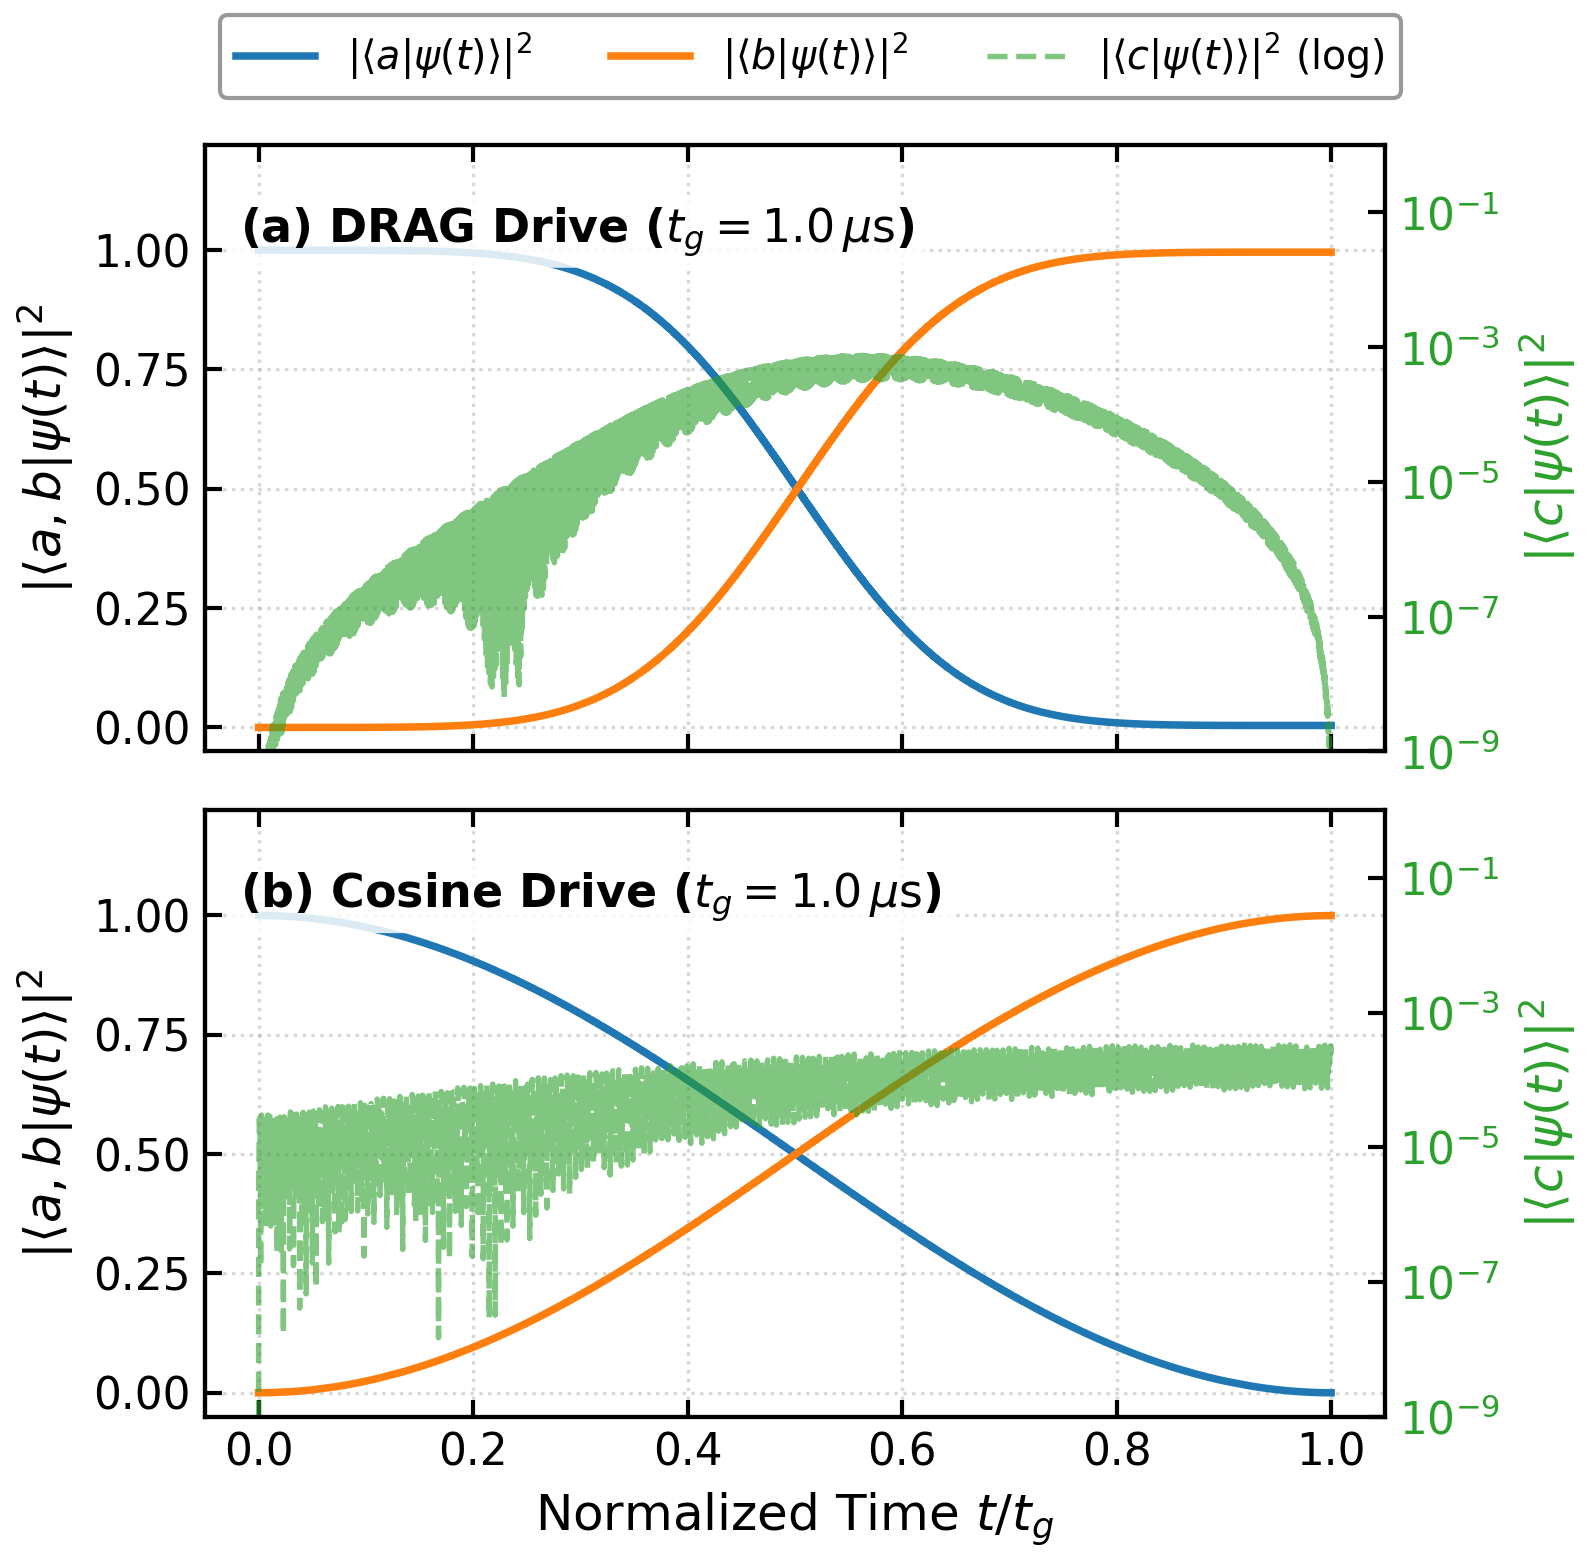

In [11]:
import matplotlib.pyplot as plt
import numpy as np

COLOR_STATE_A = "#1f77b4"  # Blau
COLOR_STATE_B = "#ff7f0e"  # Orange
COLOR_STATE_C = "#2ca02c"  # Grün

FIG_DIMENSIONS = (5.2, 5.2)  # BxH in Zoll


def plot_drag_vs_cosine_paper(data, save_filename="drag_vs_cosine_1us.png"):
    """
    Erstellt einen Vergleichsplot zwischen DRAG und Cosine Drive.
    States |a> und |b> liegen auf der linken linearen Achse, 
    State |c> auf der rechten logarithmischen Achse (twinx).
    """
    plt.rcParams.update(PAPER_STYLE)

    fig, axes = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=FIG_DIMENSIONS, 
        sharex=True, 
        sharey=True,
        constrained_layout=True
    )

    # Platz für die obere Legende freihalten
    fig.get_layout_engine().set(rect=[0, 0, 1, 0.92])

    t_norm = data["t_norm"]
    tg_us = data["tg_us"]
    tg_ns = data["tg_ns"]

    cases = [
        ("drag", f"(a) DRAG Drive ($t_g = {tg_us:.1f}\\,\\mu\\mathrm{{s}}$)"),
        ("cosine", f"(b) Cosine Drive ($t_g = {tg_us:.1f}\\,\\mu\\mathrm{{s}}$)")
    ]

    legend_handles = []

    for idx, (key, title_text) in enumerate(cases):
        ax = axes[idx]
        pops = data[key]

        # 1. Hauptachse links (linear für |a> und |b>)
        line_a, = ax.plot(t_norm, pops["state_a"], color=COLOR_STATE_A, ls="-", label=r"$|\langle a|\psi(t)\rangle|^2$")
        line_b, = ax.plot(t_norm, pops["state_b"], color=COLOR_STATE_B, ls="-", label=r"$|\langle b|\psi(t)\rangle|^2$")

        # 2. Zweite Achse rechts (logarithmisch für |c>)
        ax_c = ax.twinx()
        state_c_safe = np.maximum(pops["state_c"], 1e-12)
        
        # NEU: Transparenz (alpha=0.6) und etwas schmalere Linie (linewidth=1.3)
        line_c, = ax_c.plot(
            t_norm, 
            state_c_safe, 
            color=COLOR_STATE_C, 
            ls="--", 
            alpha=0.6, 
            linewidth=1.3,
            label=r"$|\langle c|\psi(t)\rangle|^2$ (log)"
        )
        
        ax_c.set_yscale("log")
        # NEU: Unteres Limit auf 1e-9 erweitert
        ax_c.set_ylim(1e-9, 1.0)  
        ax_c.set_ylabel(r"$|\langle c|\psi(t)\rangle|^2$", color=COLOR_STATE_C)
        ax_c.tick_params(axis="y", labelcolor=COLOR_STATE_C, direction="in")

        if idx == 0:
            legend_handles = [line_a, line_b, line_c]

        # Grid & Limits für linke Achse
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.set_ylabel(r"$|\langle a,b|\psi(t)\rangle|^2$")
        ax.set_ylim(-0.05, 1.22)

        # Panel Label
        ax.text(
            0.03, 0.84, title_text, 
            transform=ax.transAxes, 
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        ax.tick_params(direction="in", top=True)

    # X-Achse unten
    axes[-1].set_xlabel(r"Normalized Time $t / t_g$")

    # Dreispaltige Legende oben zentriert
    fig.legend(
        handles=legend_handles, 
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.925), 
        ncol=3, 
        frameon=True, 
        edgecolor="gray"
    )

    if save_filename:
        plt.savefig(save_filename)
        print(f"Plot für tg = {tg_us:.1f} µs ({tg_ns:.0f} ns) gespeichert unter: {save_filename}")

    plt.show()

# --- Aufruf ---
plot_drag_vs_cosine_paper(comparison_data, save_filename="Figure/drag_vs_cosine_1us.png")

## Population Time Evolution for Different Gate Times $t_g$

Computation and visualization of state trajectories $|\langle i|\psi(t)\rangle|^2$ over normalized time $t/t_g$ for various gate durations $t_g$:

* **`compute_population_trajectories_for_tgs`:** 
  * Optimizes DRAG pulse shapes for an ensemble of gate times $t_g$.
  * Computes the time-dependent quantum dynamics (direct simulation starting from state $a$) and optionally reconstructs trajectories using Floquet/$\mathcal{H}_{\mathrm{eff}}$ theory.
* **`plot_paper_style_population_comparison`:** 
  * Generates a publication-ready multi-panel figure for three selected gate times.
  * Compares the population dynamics of states $|a\rangle$ and $|b\rangle$ (along with optional Floquet approximations) over normalized time $t/t_g$.

In [14]:
import os
import pickle
import numpy as np
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from tqdm import tqdm


def _generate_readable_filename(tg_list, s, N_t, sigma, rH, rW, include_floquet, compute_infidelity):
    """
    Erstellt einen lesbaren Dateinamen, in dem alle Parameter im Klartext nacheinander aufgeführt sind.
    """
    # 1. tg_list kompakt zusammenfassen (z.B. tg_10.0to50.0_n5)
    tg_arr = np.array(tg_list)
    if len(tg_arr) > 1:
        tg_str = f"tg_{tg_arr[0]:.2f}to{tg_arr[-1]:.2f}_n{len(tg_arr)}"
    elif len(tg_arr) == 1:
        tg_str = f"tg_{tg_arr[0]:.2f}"
    else:
        tg_str = "tg_empty"

    # 2. Kennung für das System s (nutzt s.name falls vorhanden, sonst den Klassennamen)
    s_str = f"sys_{getattr(s, 'name', s.__class__.__name__)}"

    # 3. Alle Einzelparameter im Dateinamen verknüpfen
    filename = (
        f"res_{tg_str}_{s_str}_Nt{N_t}_sig{sigma}_rH{rH}_rW{rW}_"
        f"floq{int(include_floquet)}_infid{int(compute_infidelity)}.pkl"
    )
    
    # In Dateinamen ungültige/problematische Zeichen vorsichtshalber ersetzen
    filename = filename.replace(" ", "_").replace("/", "_")
    return filename


def compute_population_trajectories_for_tgs(
    tg_list, 
    s, 
    N_t=200, 
    sigma=0.2,          
    rH=2, 
    rW=1, 
    include_floquet=True,
    compute_infidelity=True
):
    """
    Berechnet die Zeitentwicklung der Populationen. 
    Speichert/Lädt Ergebnisse in 'operational_res' mit transparentem Dateinamen.
    """
    save_dir = "operational_res"
    os.makedirs(save_dir, exist_ok=True)

    # 1. Dateinamen direkt aus allen Parametern zusammensetzen
    filename = _generate_readable_filename(
        tg_list, s, N_t, sigma, rH, rW, include_floquet, compute_infidelity
    )
    filepath = os.path.join(save_dir, filename)

    print(f"[Cache-Check] Zieldatei: {filepath}")

    # 2. Prüfen, ob das File bereits existiert
    if os.path.exists(filepath):
        print(f"--> Vorberechnetes Ergebnis aus '{filename}' geladen.")
        with open(filepath, "rb") as f:
            return pickle.load(f)

    # 3. Falls nicht vorhanden, Berechnung durchführen
    print("--> Kein passendes File gefunden. Starte Berechnung...")
    simulation_results = []
    bounds = (
        [0.7 * 2 * np.pi, -2 * np.pi, -np.pi / 4],
        [0.712 * 2 * np.pi, 2 * np.pi, np.pi / 4],
    )

    for tg in tg_list:
        tlist = np.linspace(0, tg, N_t)
        
        # --- 1. Target & Parameter ---
        cos_amp, cos_wd = compute_cos_params(s, tg)
        heff_params = s.heff(cos_wd, cos_amp)
        Delta = heff_params[2][2] - heff_params[0][0]
        rrr = heff_params[1][2] / heff_params[0][1]
        ht, _ = h_target(Delta, rrr, tg, sigma_r=sigma)
        ht_func = lambda t: ht[0] + sum(h[0] * h[1](t) for h in ht[1:])
        
        # --- 2. Pulse Shape Calculation ---
        freq, ar, ai = [], [], []
        prev_sol = [cos_wd, cos_amp, 0]

        for t in tqdm(tlist, desc=f"Pulse Shape (tg={tg})", leave=False):
            ht_t = ht_func(t)
            def res(x):
                w, a_r, a_i = x
                amp = a_r + 1j * a_i
                diff_diag = (heff_fit(coeffs00, w, amp) - heff_fit(coeffs11, w, amp)) - (ht_t[0, 0] - ht_t[1, 1])
                diff_off = heff_fit(coeffs01, w, amp) - ht_t[0, 1]
                return [abs(diff_diag), np.real(diff_off), np.imag(diff_off)]

            opt = least_squares(res, x0=prev_sol, bounds=bounds)
            prev_sol = opt.x
            freq.append(opt.x[0])
            ar.append(opt.x[1])
            ai.append(opt.x[2])
            
        f_wd = interp1d(tlist, freq, kind="linear", bounds_error=False, fill_value=(freq[0], freq[-1]))
        f_ar = interp1d(tlist, ar, kind="linear", bounds_error=False, fill_value=(ar[0], ar[-1]))
        f_ai = interp1d(tlist, ai, kind="linear", bounds_error=False, fill_value=(ai[0], ai[-1]))

        def qutip_signal(t, args=None):
            return float(f_ar(t)) * np.cos(float(f_wd(t)) * t) + float(f_ai(t)) * np.sin(float(f_wd(t)) * t)

        def drive_signal_interp(t):
            return [float(f_wd(t)), float(f_ar(t)) + 1j * float(f_ai(t))]

        # --- 3. Direkte Simulation (Dynamics) ---
        lh = [s.H0, [s.V1, qutip_signal]]
        amp_a = resonant_subspace_column_evolution(lh, tlist, 0, debug=False, s=s)

        res_dict = {
            "tg": tg,
            "t_norm": tlist / tg,
            "direct": {
                "state_a": np.abs(amp_a[0])**2, 
                "state_b": np.abs(amp_a[1])**2,
                "state_c": np.abs(amp_a[2])**2 if len(amp_a) > 2 else None
            }
        }

        if compute_infidelity:
            amp_b = resonant_subspace_column_evolution(lh, tlist, 1, debug=False, s=s)
            p_ab = res_dict["direct"]["state_b"][-1]
            p_ba = np.abs(amp_b[0][-1])**2
            res_dict["fidelity_direct"] = 0.5 * (p_ab + p_ba)

        # --- 4. Floquet / Heff Simulation (Optional) ---
        if include_floquet:
            sub_t_number = 10
            psi_floq_a = Psi_t_from_Heff(
                rH, rW, drive_signal_interp, s.resonances, s.E_array, 
                s.V1_dressed_array, s.E_states[s.state_a], tlist, 
                None, None, True, True, True, False, sub_t_number
            )
            res_dict["floquet"] = {
                "state_a": np.abs(psi_floq_a[s.state_a])**2, 
                "state_b": np.abs(psi_floq_a[s.state_b])**2,
                "state_c": np.abs(psi_floq_a[s.state_c])**2 if hasattr(s, "state_c") else None
            }

            if compute_infidelity:
                psi_floq_b = Psi_t_from_Heff(
                    rH, rW, drive_signal_interp, s.resonances, s.E_array, 
                    s.V1_dressed_array, s.E_states[s.state_b], tlist, 
                    None, None, True, True, True, False, sub_t_number
                )
                p_fl_ab = res_dict["floquet"]["state_b"][-1]
                p_fl_ba = np.abs(psi_floq_b[s.state_a][-1])**2
                res_dict["fidelity_floquet"] = 0.5 * (p_fl_ab + p_fl_ba)

        simulation_results.append(res_dict)

    # 4. Fertiges Ergebnis im Ordner abspeichern
    with open(filepath, "wb") as f:
        pickle.dump(simulation_results, f)
    print(f"--> Ergebnis gespeichert unter '{filepath}'.")

    return simulation_results

In [17]:
results = compute_population_trajectories_for_tgs([1000, 500, 250], s, include_floquet=False)

[Cache-Check] Zieldatei: operational_res/res_tg_1000.00to250.00_n3_sys_Simulation_Nt200_sig0.2_rH2_rW1_floq0_infid1.pkl
--> Vorberechnetes Ergebnis aus 'res_tg_1000.00to250.00_n3_sys_Simulation_Nt200_sig0.2_rH2_rW1_floq0_infid1.pkl' geladen.


In [18]:
def generate_latex_infidelity_table(simulation_results):
    has_floquet = "fidelity_floquet" in simulation_results[0]
    latex_str = [
        r"\begin{table}[htbp]",
        r"  \centering",
        r"  \caption{Population infidelity $\mathcal{I}_{\mathrm{pop}} = 1 - \frac{1}{2}\left[P_{a\to b}(t_g) + P_{b\to a}(t_g)\right]$ for various gate times $t_g$.}",
        r"  \label{tab:population_infidelity}",
    ]
    if has_floquet:
        latex_str.extend([
            r"  \begin{tabular}{ccc}",
            r"    \hline\hline",
            r"    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{pop}}\ (\mathrm{Direct})$ & $\mathcal{I}_{\mathrm{pop}}\ (\mathrm{Floquet})$ \\",
            r"    \hline"
        ])
    else:
        latex_str.extend([
            r"  \begin{tabular}{cc}",
            r"    \hline\hline",
            r"    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{pop}}\ (\mathrm{Direct})$ \\",
            r"    \hline"
        ])

    for res in simulation_results:
        tg_ns = res["tg"]
        infid_dir = 1.0 - res["fidelity_direct"]

        if has_floquet:
            infid_floq = 1.0 - res["fidelity_floquet"]
            latex_str.append(
                f"    {tg_ns:.0f} & {infid_dir:.2e} & {infid_floq:.2e} \\\\"
            )
        else:
            latex_str.append(
                f"    {tg_ns:.0f} & {infid_dir:.2e} \\\\"
            )

    latex_str.extend([
        r"    \hline\hline",
        r"  \end{tabular}",
        r"\end{table}"
    ])

    code = "\n".join(latex_str)
    print(code)
    return code
# Ausgeben des LaTeX-Codes für die Tabelle:
latex_table_code = generate_latex_infidelity_table(results)

\begin{table}[htbp]
  \centering
  \caption{Population infidelity $\mathcal{I}_{\mathrm{pop}} = 1 - \frac{1}{2}\left[P_{a\to b}(t_g) + P_{b\to a}(t_g)\right]$ for various gate times $t_g$.}
  \label{tab:population_infidelity}
  \begin{tabular}{cc}
    \hline\hline
    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{pop}}\ (\mathrm{Direct})$ \\
    \hline
    1000 & 4.17e-03 \\
    500 & 2.19e-02 \\
    250 & 1.43e-01 \\
    \hline\hline
  \end{tabular}
\end{table}


Plot erfolgreich gespeichert unter: Figure/aresonant_exchange.png


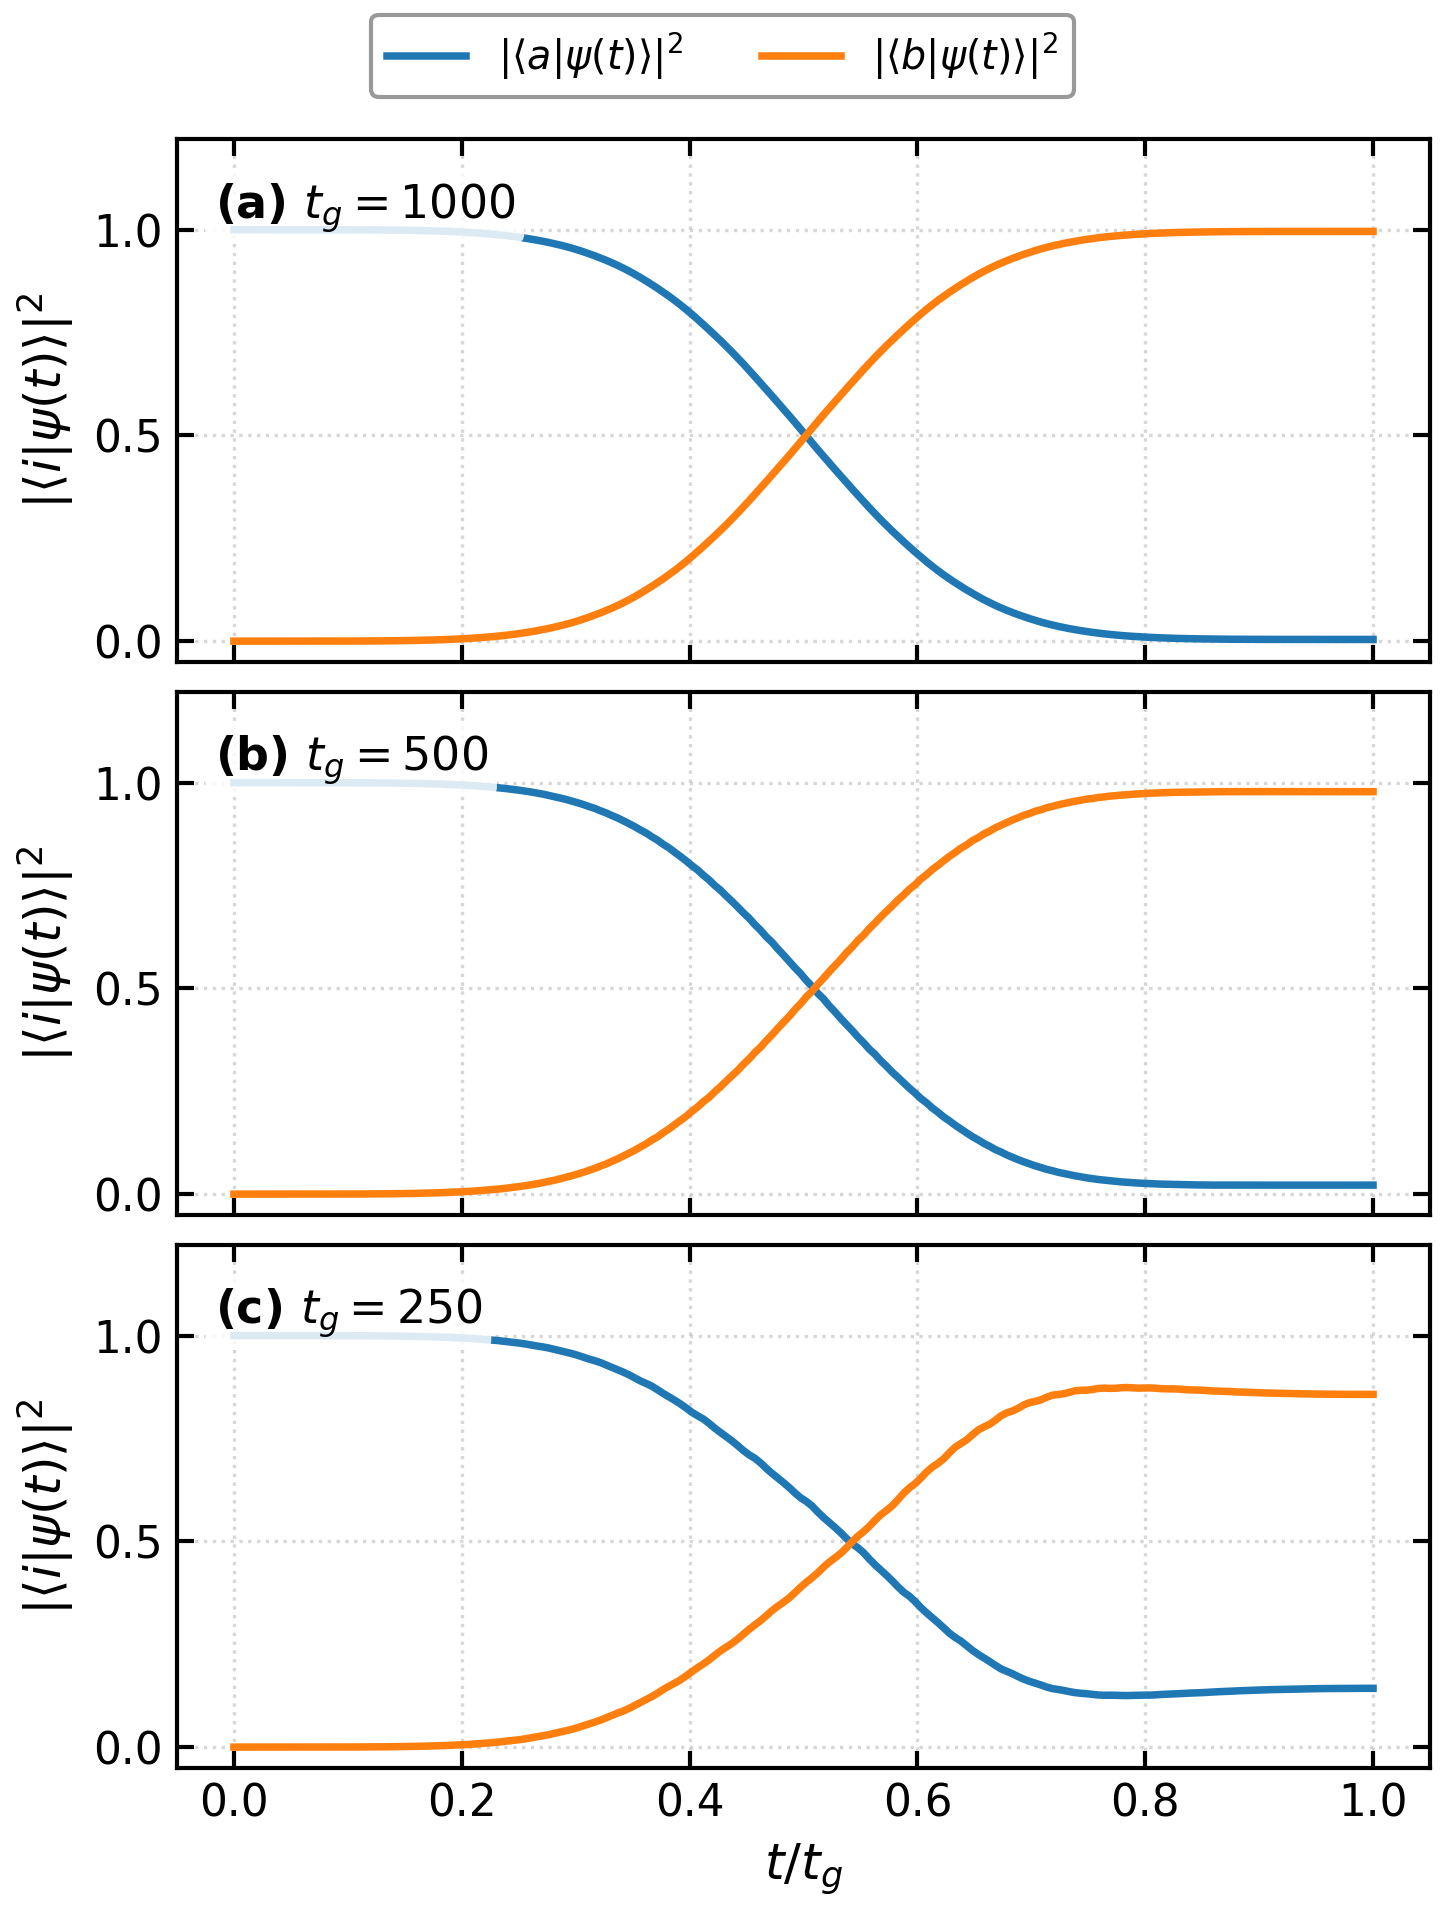

In [19]:
import matplotlib.pyplot as plt

# Farben & Dimensionen
COLOR_STATE_A = "#1f77b4"  # Blau
COLOR_STATE_B = "#ff7f0e"  # Orange


# =============================================================================
# PLOT-FUNKTION
# =============================================================================
def plot_paper_style_population_comparison(
    simulation_results, 
    include_floquet=True, 
    save_filename="population_dynamics_paper.pdf"
):
    r"""
    Plottet die Zeitentwicklung der Betragsquadrate der Wellenfunktion |\langle i|\psi(t)\rangle|^2
    für alle in simulation_results enthaltenen Gate-Zeiten vertikal untereinander im Paper-Style.
    """
    # Globales Style-Setup anwenden
    plt.rcParams.update(PAPER_STYLE)

    num_plots = len(simulation_results)
    if num_plots == 0:
        print("Keine Ergebnisse zum Plotten übergeben.")
        return

    # Höhe dynamisch skalieren (2.13 Zoll pro Subplot)
    fig_dimensions = (4.8, 2.13 * num_plots)

    # Figure & Axes dynamisch anhand der Anzahl an Ergebnissen erstellen
    fig, axes = plt.subplots(
        nrows=num_plots, 
        ncols=1, 
        figsize=fig_dimensions, 
        sharex=True, 
        sharey=True,
        constrained_layout=True
    )

    # Falls nur 1 Plot übergeben wurde, 'axes' als Liste/Array behandeln
    if num_plots == 1:
        axes = [axes]

    # Platz oben freihalten für die gemeinsame Legende
    fig.get_layout_engine().set(rect=[0, 0, 1, 0.93])

    legend_handles = []

    for idx, res in enumerate(simulation_results):
        ax = axes[idx]
        t_norm = res["t_norm"]
        tg = res["tg"]

        # 1. Direkte Simulation: Betragsquadrat der Projektion
        line_dir_a, = ax.plot(
            t_norm, res["direct"]["state_a"], 
            color=COLOR_STATE_A, ls="-", 
            label=r"$|\langle a|\psi(t)\rangle|^2$"
        )
        line_dir_b, = ax.plot(
            t_norm, res["direct"]["state_b"], 
            color=COLOR_STATE_B, ls="-", 
            label=r"$|\langle b|\psi(t)\rangle|^2$"
        )

        if idx == 0:
            legend_handles.extend([line_dir_a, line_dir_b])

        # 2. Optional: Floquet Simulation
        if include_floquet and "floquet" in res:
            line_floq_a, = ax.plot(
                t_norm, res["floquet"]["state_a"], 
                color=COLOR_STATE_A, ls="--", 
                label=r"Floquet $|\langle a|\psi(t)\rangle|^2$"
            )
            line_floq_b, = ax.plot(
                t_norm, res["floquet"]["state_b"], 
                color=COLOR_STATE_B, ls="--", 
                label=r"Floquet $|\langle b|\psi(t)\rangle|^2$"
            )
            if idx == 0:
                legend_handles.extend([line_floq_a, line_floq_b])

        # Grid & Limits
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.set_ylabel(r"$|\langle i|\psi(t)\rangle|^2$")
        ax.set_ylim(-0.05, 1.22)  # Verhindert Überdeckung bei y=1.0

        # Dynamisches Panel-Label: (a), (b), (c), ...
        panel_label = f"({chr(97 + idx)})"
        ax.text(
            0.03, 0.85, f"{panel_label} $t_g = {tg}$", 
            transform=ax.transAxes, 
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        ax.tick_params(direction="in", top=True, right=True)

    # Beschriftung der x-Achse am untersten Subplot
    axes[-1].set_xlabel(r"$t / t_g$")

    # Legende zentriert über den Subplots
    fig.legend(
        handles=legend_handles, 
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.935), 
        ncol=2, 
        frameon=True, 
        edgecolor="gray"
    )

    # Speichern in hoher Auflösung
    if save_filename:
        plt.savefig(save_filename)
        print(f"Plot erfolgreich gespeichert unter: {save_filename}")
        
    plt.show()
# --- Aufruf ---
plot_paper_style_population_comparison(results, include_floquet=False, save_filename="Figure/aresonant_exchange.png")

## Population Trajectories with Floquet Theory Comparison

Execution of the simulation for a refined set of gate times $t_g$ with active Floquet / $\mathcal{H}_{\mathrm{eff}}$ reconstruction (`include_floquet=True`):

* **Parameter Sweep:** Evaluates various gate durations $t_g$ (e.g., $800\,\mathrm{ns}$, $400\,\mathrm{ns}$, $200\,\mathrm{ns}$, $100\,\mathrm{ns}$) to analyze dynamics in both adiabatic and strongly non-adiabatic regimes.
* **Floquet Reconstruction:** Computes time evolution using effective Hamiltonian theory with truncation radii $r_H = 2$ and $r_W = 1$ to benchmark quasi-energy dynamics against direct time integration.
* **Infidelity Analysis:** Generates the updated LaTeX summary table contrasting direct integration infidelities $\mathcal{I}_{\mathrm{direct}}$ with Floquet predictions $\mathcal{I}_{\mathrm{floquet}}$.

In [ ]:
# 1. Parameter für den neuen Durchlauf festlegen (z. B. kürzere/geänderte Gate-Zeiten)
tg_list_floquet = [500, 200, 100]

# 2. Berechnung inklusive Floquet/Heff-Vorhersage ausführen
results_floquet = compute_population_trajectories_for_tgs(
    tg_list=tg_list_floquet,
    s=s,
    N_t=150,
    sigma=0.2,
    rH=3,
    rW=2,
    include_floquet=True,
)

Kein passender Cache gefunden. Starte Berechnung...


  0%|          | 0/150 [00:00<?, ?it/s]                                  


TypeError: Heff_Floquet_summed() got multiple values for argument 'V0'

In [ ]:
def generate_latex_infidelity_table(simulation_results):
    """
    Erstellt den LaTeX-Code für eine Tabelle der Population Infidelities
    und der absoluten Differenz zwischen Direct und Floquet.
    """
    has_floquet = "fidelity_floquet" in simulation_results[0]

    latex_str = [
        r"\begin{table}[htbp]",
        r"  \centering",
        r"  \caption{Population infidelity $\mathcal{I}_{\mathrm{pop}} = 1 - F_{\mathrm{pop}}$ for various gate times $t_g$ alongside the absolute deviation $\Delta \mathcal{I} = |\mathcal{I}_{\mathrm{Direct}} - \mathcal{I}_{\mathrm{Floquet}}|$ between direct simulation and Floquet theory.}",
        r"  \label{tab:population_infidelity}",
    ]

    if has_floquet:
        latex_str.extend([
            r"  \begin{tabular}{cccc}",
            r"    \hline\hline",
            r"    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{Direct}}$ & $\mathcal{I}_{\mathrm{Floquet}}$ & $\Delta \mathcal{I}$ \\",
            r"    \hline"
        ])
    else:
        latex_str.extend([
            r"  \begin{tabular}{cc}",
            r"    \hline\hline",
            r"    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{Direct}}$ \\",
            r"    \hline"
        ])

    for res in simulation_results:
        tg_ns = res["tg"]
        infid_dir = 1.0 - res["fidelity_direct"]

        if has_floquet:
            infid_floq = 1.0 - res["fidelity_floquet"]
            diff = abs(infid_dir - infid_floq)
            latex_str.append(
                f"    {tg_ns:.0f} & {infid_dir:.2e} & {infid_floq:.2e} & {diff:.2e} \\\\"
            )
        else:
            latex_str.append(
                f"    {tg_ns:.0f} & {infid_dir:.2e} \\\\"
            )

    latex_str.extend([
        r"    \hline\hline",
        r"  \end{tabular}",
        r"\end{table}"
    ])

    code = "\n".join(latex_str)
    print(code)
    return code
# 3. LaTeX-Tabelle mit Infidelities (Direct vs. Floquet) generieren
latex_table_code = generate_latex_infidelity_table(results_floquet)

\begin{table}[htbp]
  \centering
  \caption{Population infidelity $\mathcal{I}_{\mathrm{pop}} = 1 - F_{\mathrm{pop}}$ for various gate times $t_g$ alongside the absolute deviation $\Delta \mathcal{I} = |\mathcal{I}_{\mathrm{Direct}} - \mathcal{I}_{\mathrm{Floquet}}|$ between direct simulation and Floquet theory.}
  \label{tab:population_infidelity}
  \begin{tabular}{cccc}
    \hline\hline
    $t_g\ (\mathrm{ns})$ & $\mathcal{I}_{\mathrm{Direct}}$ & $\mathcal{I}_{\mathrm{Floquet}}$ & $\Delta \mathcal{I}$ \\
    \hline
    500 & 2.19e-02 & 2.17e-02 & 1.87e-04 \\
    200 & 2.55e-01 & 2.54e-01 & 1.52e-03 \\
    100 & 7.89e-01 & 7.66e-01 & 2.34e-02 \\
    \hline\hline
  \end{tabular}
\end{table}


Plot erfolgreich gespeichert unter: Figure/aresonant_exchange_floquet.png


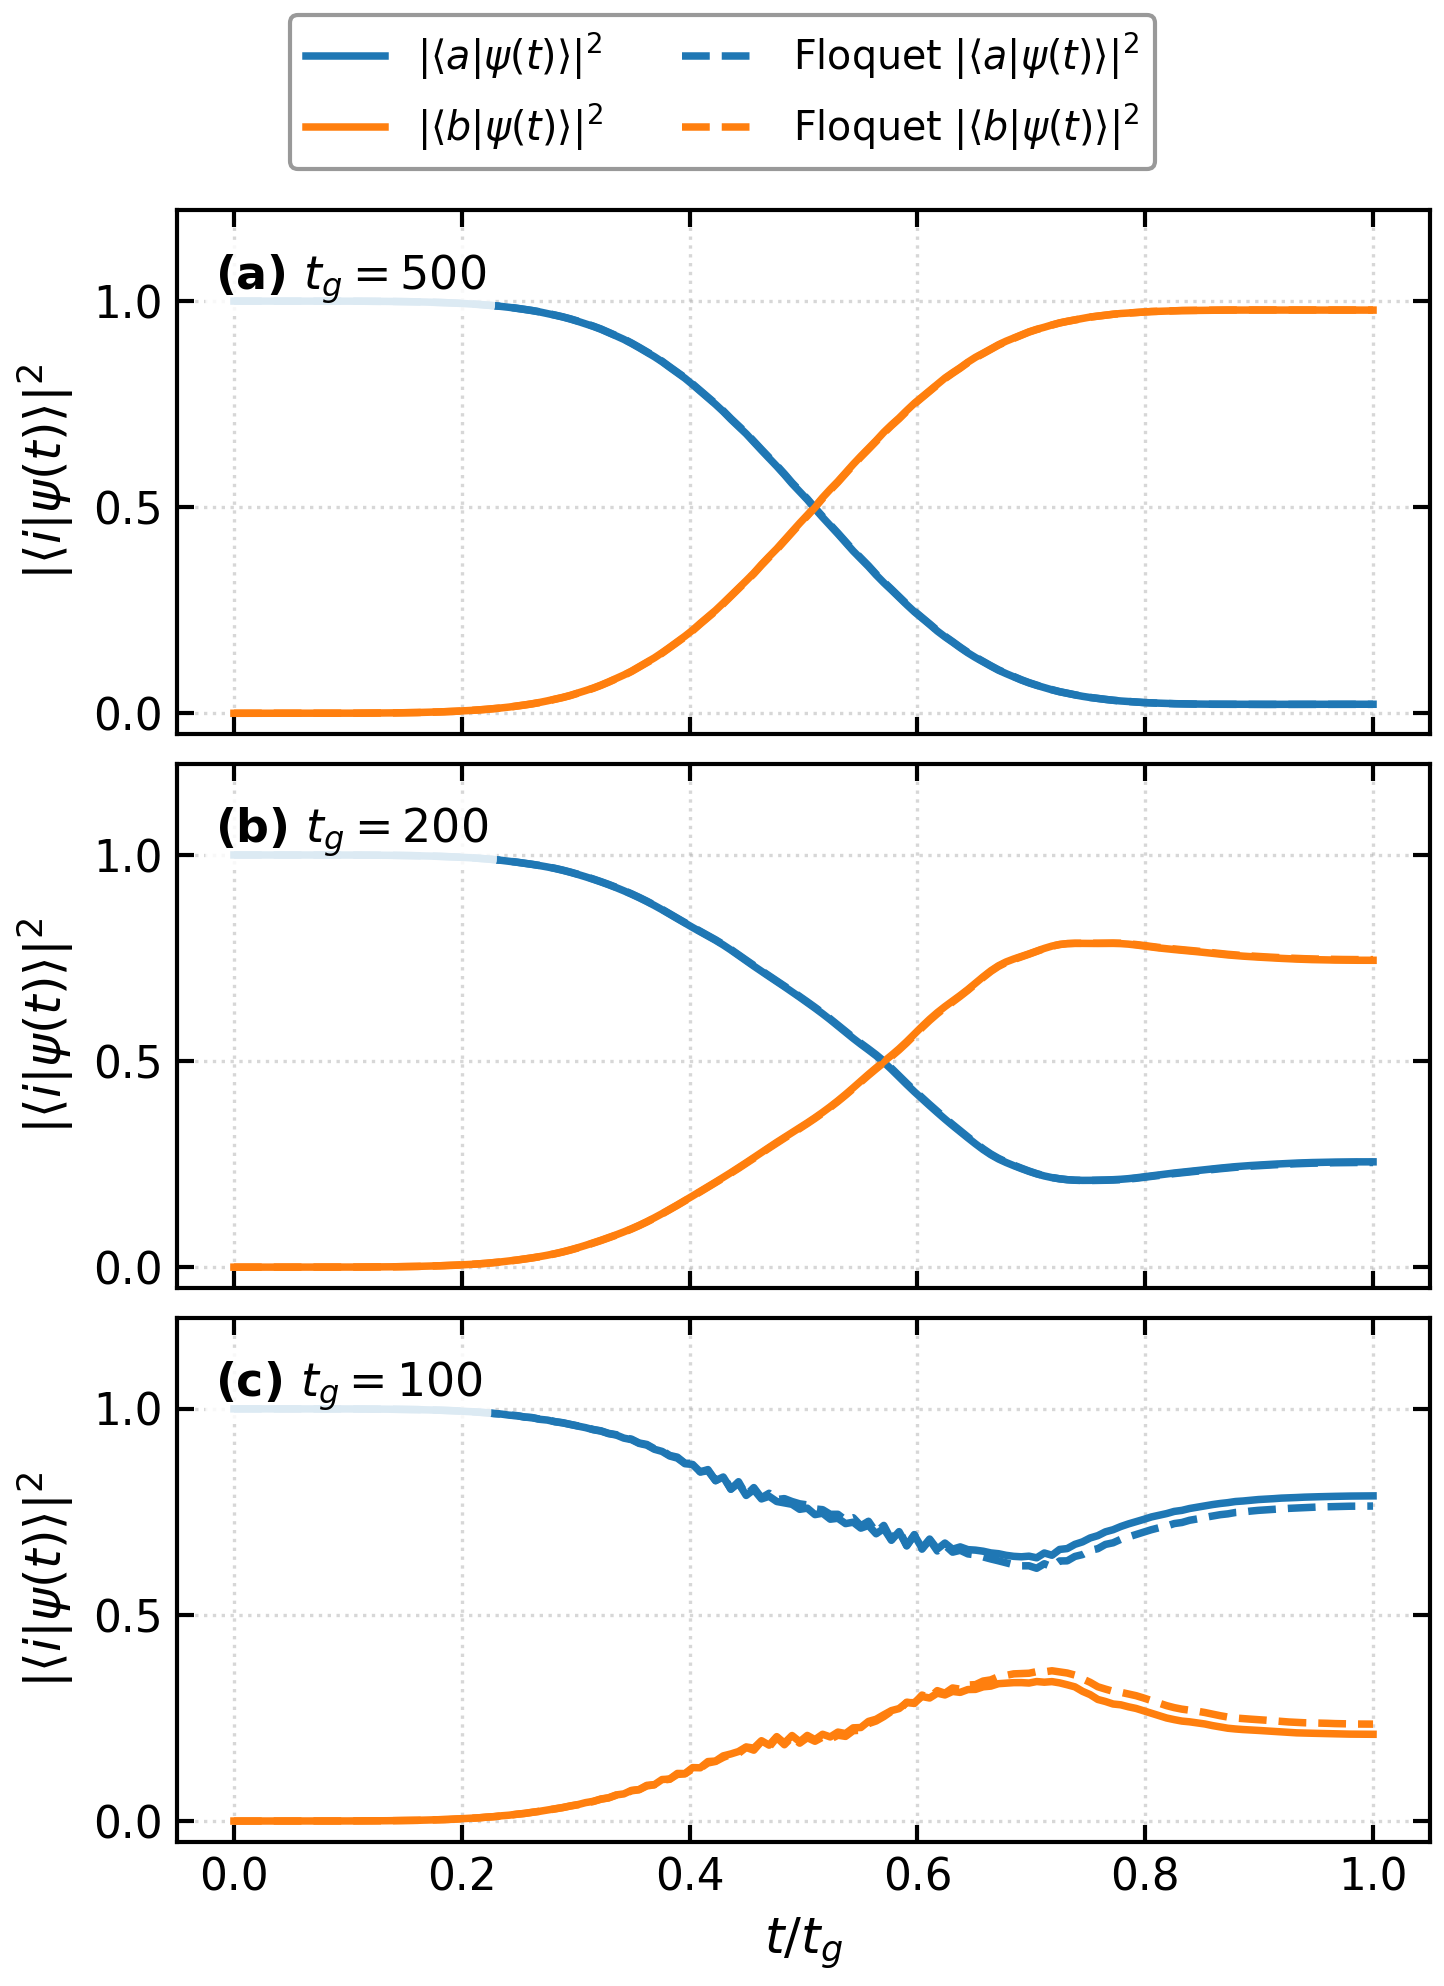

In [ ]:
plot_paper_style_population_comparison(
    simulation_results=results_floquet, 
    include_floquet=True, 
    save_filename="Figure/aresonant_exchange_floquet.png"
)

## Limits of Floquet Prediction at Fast Gate Times ($\sigma = 0.1 \cdot t_g$)

Investigation of the breakdown regime for ultra-fast gate durations ($t_g \le 100\,\mathrm{ns}$) using a narrowed Gaussian DRAG envelope ($\sigma = 0.1 \cdot t_g$):

* **Narrow Pulse Shape:** A smaller $\sigma$ yields a significantly reduced $\mathrm{FWHM} \approx 0.235 \cdot t_g$, leading to sharp pulse transients and high spectral bandwidth.
* **Non-Adiabatic Dynamics:** Benchmarks direct integration against Floquet/$\mathcal{H}_{\mathrm{eff}}$ theory to identify where the effective Hamiltonian approximation fails to resolve rapid drive variations.
* **Outputs:** Generates population infidelity metrics ($\mathcal{I}_{\mathrm{Direct}}$ vs. $\mathcal{I}_{\mathrm{Floquet}}$) and plots multi-panel population trajectories.

In [ ]:
# 1. Sehr kurze Gate-Zeiten festlegen (3 Werte passen perfekt zum 3-Panel-Plot)
tg_list_low = [150, 100]

# 2. Simulation mit verringertem sigma=0.1 durchführen
results_low_tg = compute_population_trajectories_for_tgs(
    tg_list=tg_list_low,
    s=s,
    N_t=200,
    sigma=0.15,          # sigma = 0.1 * tg
    rH=3,
    rW=2,
    include_floquet=True,
    compute_infidelity=False,
)

100%|█████████▉| 199/200 [10:11<00:03,  3.07s/it]                        


Plot erfolgreich gespeichert unter: Figure/floquet_limit_test.png


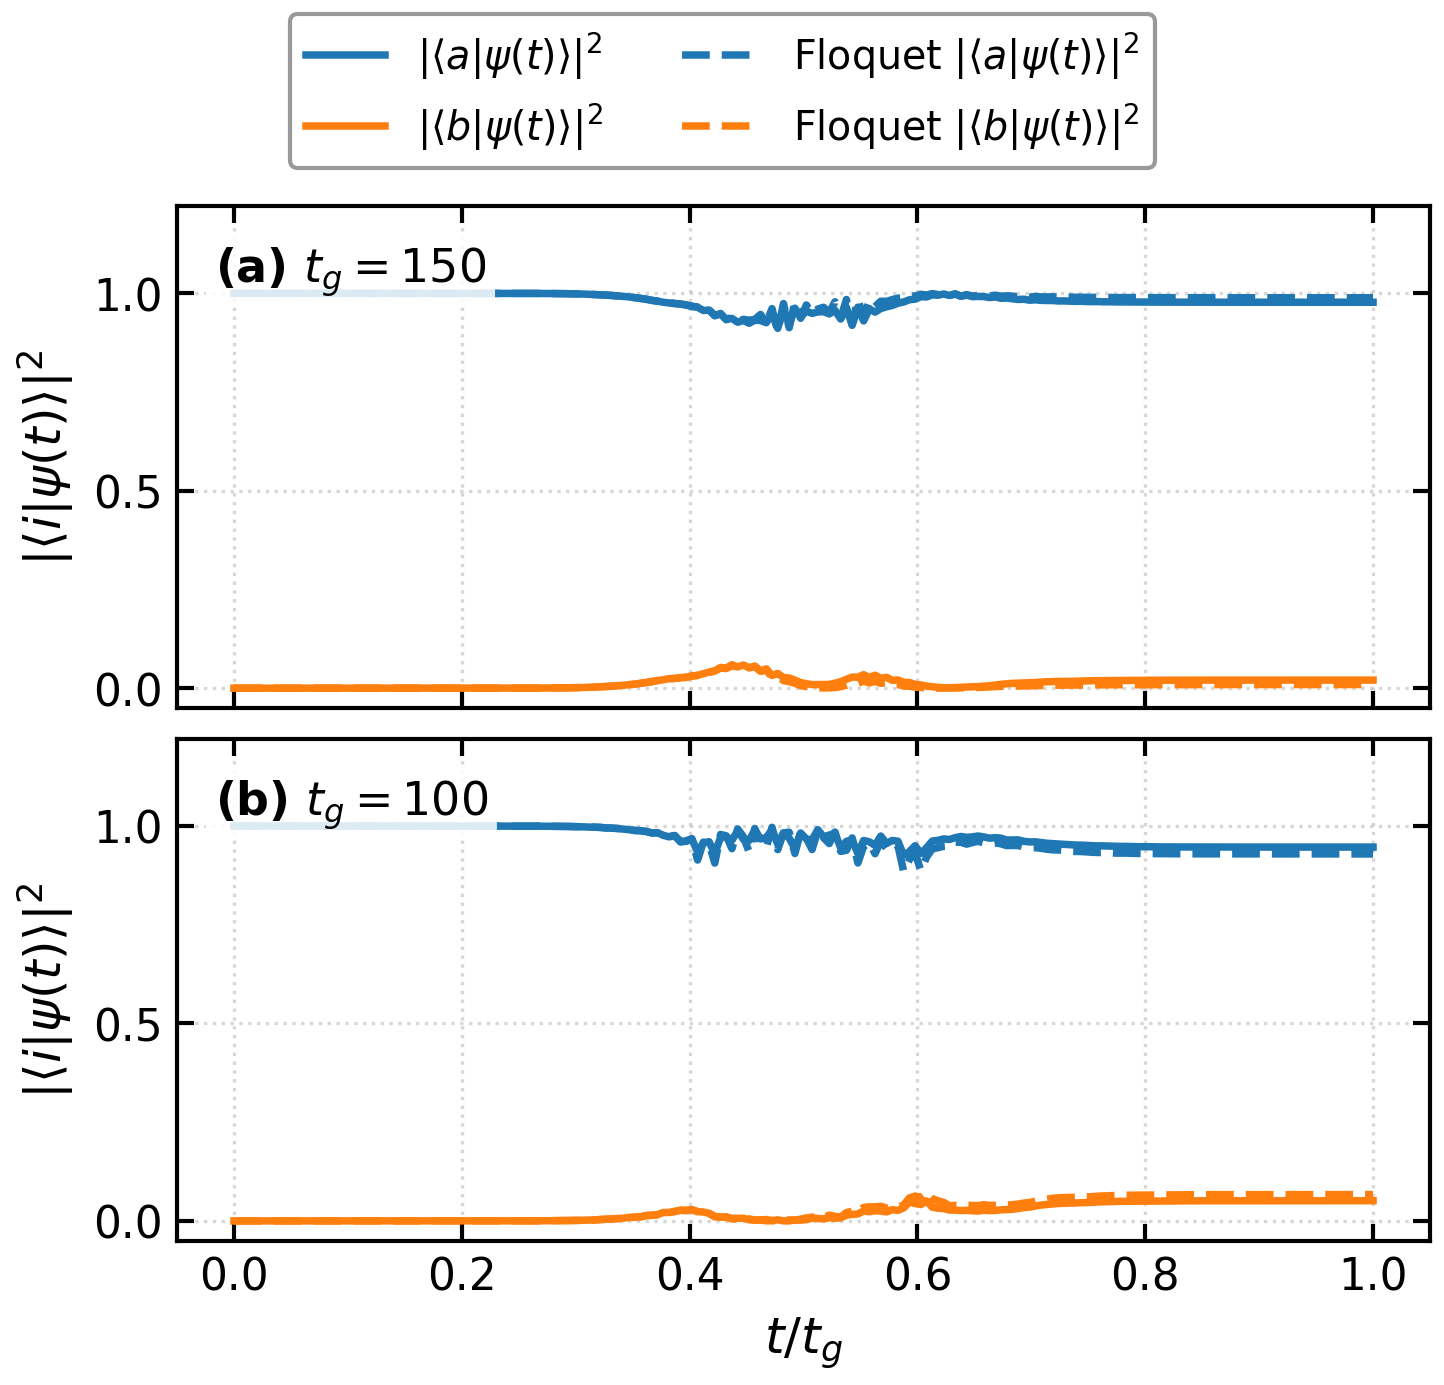

In [ ]:
plot_paper_style_population_comparison(
    simulation_results=results_low_tg, 
    include_floquet=True, 
    save_filename="Figure/floquet_limit_test.png"
) 